In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
sns.set_palette("muted")

print("Libraries loaded")

Libraries loaded


In [5]:
df = pd.read_csv('../Data/Cleaned/mta_ridership_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

In [6]:
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().strftime('%d %b %Y')} -> {df['date'].max().strftime('%d %b %Y')}")
print(f"Nulls: {df.isnull().sum().sum()}")

Loaded: 1,776 rows x 21 columns
Date range: 01 Mar 2020 -> 09 Jan 2025
Nulls: 0


In [7]:
TARGET = 'subway_ridership'

RIDERSHIP_COLS = [
    'subway_ridership', 'bus_ridership', 'lirr_ridership',
    'metro_north_ridership', 'access_ride_trips',
    'bridges_tunnels_traffic', 'staten_island_ridership'
]

BASELINE_COLS = [
    'subway_pct_baseline', 'bus_pct_baseline', 'lirr_pct_baseline',
    'metro_north_pct_baseline', 'access_ride_pct_baseline',
    'bridges_tunnels_pct_baseline', 'staten_island_pct_baseline'
]

FLAG_COLS = ['is_covid', 'is_weekend', 'is_holiday', 'is_outlier']

print(f"Variables defined")
print(f"TARGET        : {TARGET}")
print(f"Ridership cols: {len(RIDERSHIP_COLS)}")
print(f"Baseline cols : {len(BASELINE_COLS)}")
print(f"Flag cols     : {len(FLAG_COLS)}")

Variables defined
TARGET        : subway_ridership
Ridership cols: 7
Baseline cols : 7
Flag cols     : 4


In [8]:
print ('Univariate Analysis')
print (f'Column: {TARGET}')
print (f'Count: {df[TARGET].count():>12,}')
print (f'Mean : {df[TARGET].mean():>12,.0f}')
print (f'Median: {df[TARGET].median():>12,.0f}')
print(f"Std Dev: {df[TARGET].std():>12,.0f}")
print(f"Min    : {df[TARGET].min():>12,.0f}")
print(f"Max    : {df[TARGET].max():>12,.0f}")
print(f"Skew   : {df[TARGET].skew():>12.4f}")
print(f"Kurt   : {df[TARGET].kurtosis():>12.4f}")
print(f"CV     : {df[TARGET].std()/df[TARGET].mean()*100:>11.2f}%") 

Univariate Analysis
Column: subway_ridership
Count:        1,776
Mean :    2,541,830
Median:    2,505,354
Std Dev:    1,067,641
Min    :      198,399
Max    :    5,498,809
Skew   :      -0.1656
Kurt   :      -0.9273
CV     :       42.00%


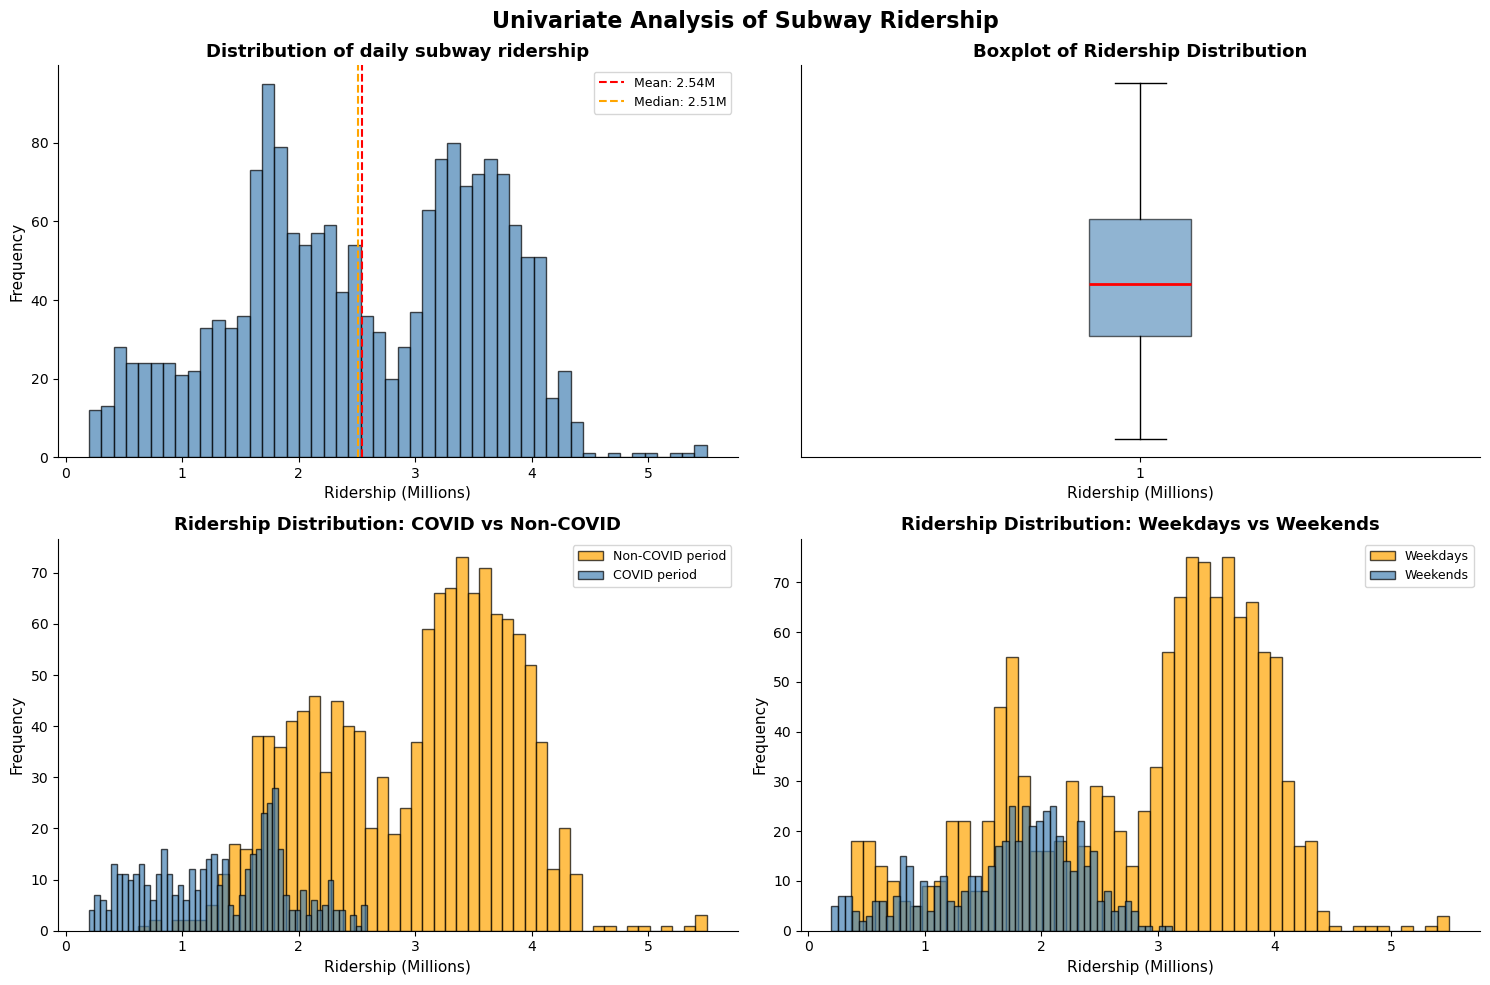

Saved to Reports


<Figure size 1400x500 with 0 Axes>

In [9]:
fig,axes = plt.subplots(2, 2, figsize=(15, 10))

#histogram for daily subway ridership
axes [0,0].hist(df[TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', alpha = 0.7)
axes[0,0].axvline(df[TARGET].mean()/1e6, color='red',
                  linestyle='--', linewidth=1.5,
                  label=f"Mean: {df[TARGET].mean()/1e6:.2f}M")
axes[0,0].axvline(df[TARGET].median()/1e6, color='orange',
                  linestyle='--', linewidth=1.5,
                  label=f"Median: {df[TARGET].median()/1e6:.2f}M")
axes[0,0].set_title(f"Distribution of daily subway ridership", fontweight='bold') 
axes[0,0].set_xlabel("Ridership (Millions)")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend(fontsize=9)

#boxplot for ridership distribution
axes[0,1].boxplot(df[TARGET]/1e6, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6),
                  medianprops=dict(color='red', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor='red',
                                  markersize=4, alpha=0.5))
axes[0,1].set_title(f"Boxplot of Ridership Distribution", fontweight='bold')
axes[0,1].set_xlabel("Ridership (Millions)")
axes[0,1].set_yticks([])

#ridership distribution: COVID vs Non-COVID
axes[1,0].hist(df[df['is_covid']==0][TARGET]/1e6, bins=50, color='orange', edgecolor='black', label = 'Non-COVID period', alpha = 0.7)
axes[1,0].hist(df[df['is_covid']==1][TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', label = 'COVID period', alpha = 0.7)
axes[1,0].set_title(f"Ridership Distribution: COVID vs Non-COVID", fontweight='bold')
axes[1,0].set_xlabel("Ridership (Millions)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend(fontsize=9)

axes[1,1].hist(df[df['is_weekend']==0][TARGET]/1e6, bins=50, color='orange', edgecolor='black', label = 'Weekdays', alpha = 0.7)
axes[1,1].hist(df[df['is_weekend']==1][TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', label = 'Weekends', alpha = 0.7)
axes[1,1].set_title(f"Ridership Distribution: Weekdays vs Weekends", fontweight='bold')
axes[1,1].set_xlabel("Ridership (Millions)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend(fontsize=9)

plt.suptitle ('Univariate Analysis of Subway Ridership', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('../Reports/03_univariate_analysis.png', dpi=150, bbox_inches='tight')
print("Saved to Reports")

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [11]:
ts = df.set_index('date')[TARGET]
decomposition = seasonal_decompose(ts, model = 'additive', period = 7)

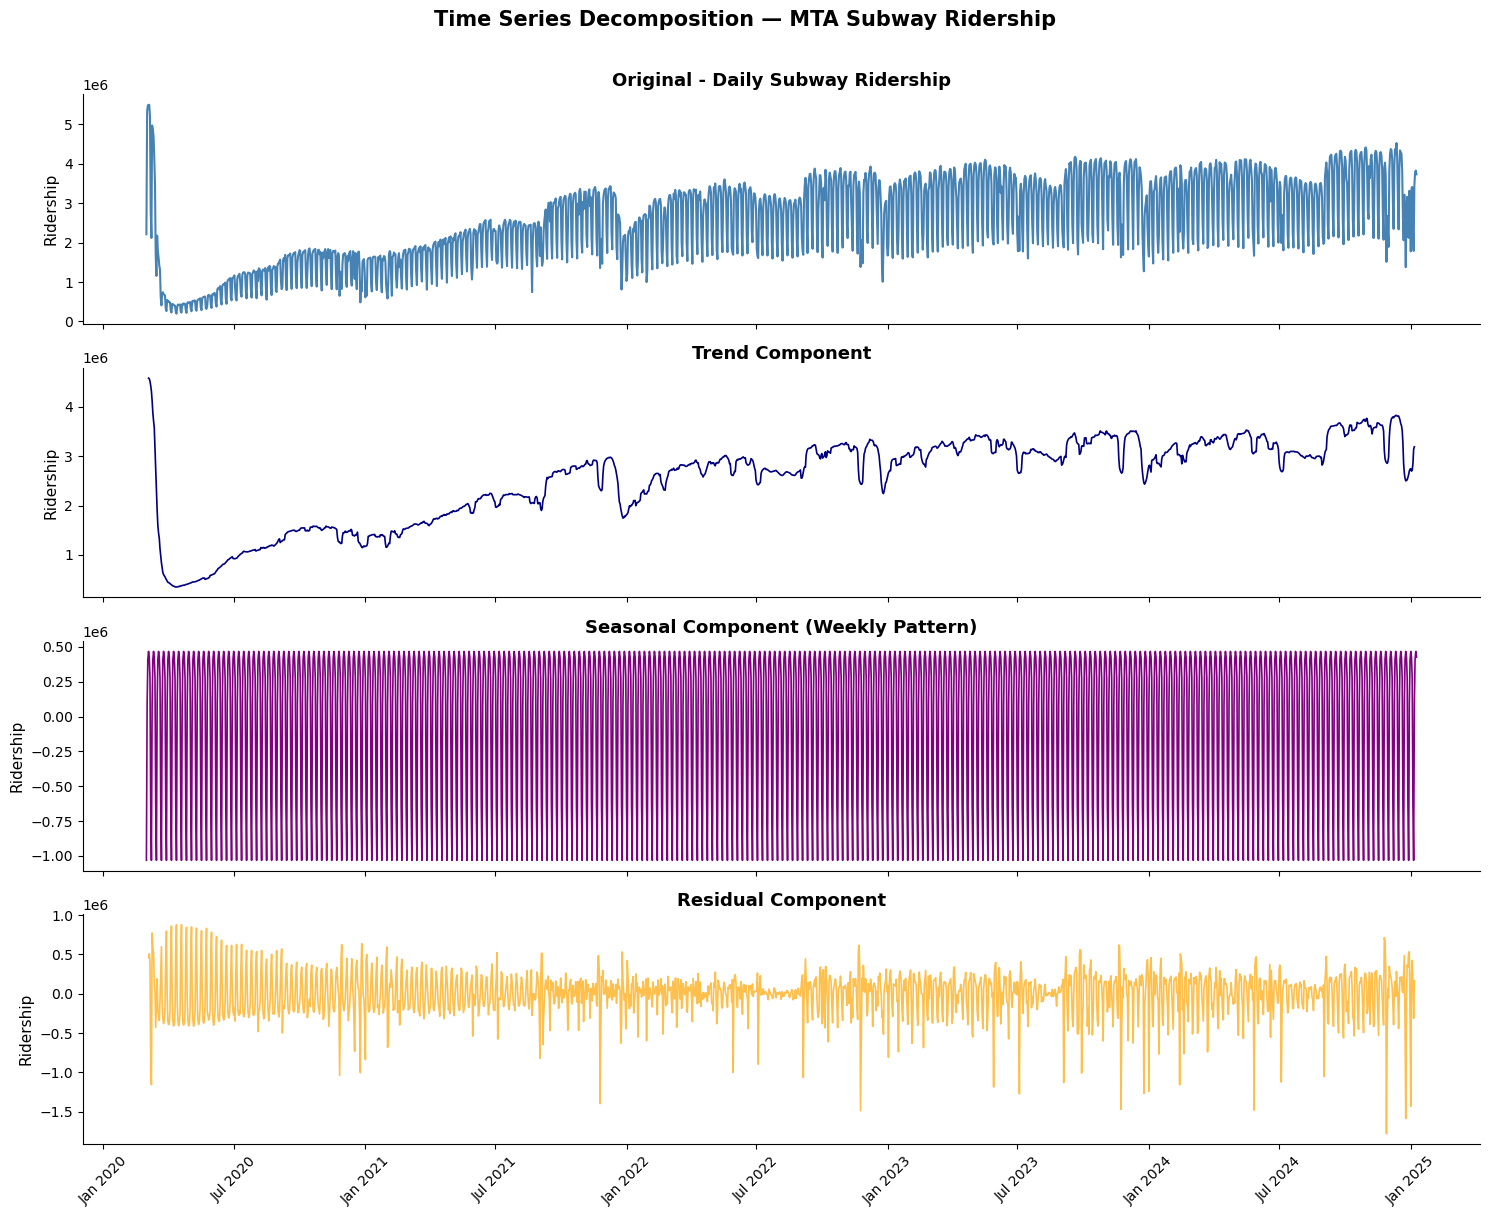

Saved to Reports


In [12]:
fig,axes = plt.subplots (4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(ts, color='steelblue', label='Original')
axes[0].set_title('Original - Daily Subway Ridership', fontweight='bold')
axes[0].set_ylabel('Ridership')

axes [1].plot(decomposition.trend, color='navy', linewidth = 1.2)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Ridership')

axes [2].plot(decomposition.seasonal, color='purple', linewidth = 1.2)
axes[2].set_title('Seasonal Component (Weekly Pattern)', fontweight='bold')
axes[2].set_ylabel('Ridership')

axes [3].plot(decomposition.resid, color='orange', linewidth = 1.2, alpha = 0.7)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Ridership')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Time Series Decomposition — MTA Subway Ridership",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports")

In [13]:
#weekly seasonality analysis
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avg_by_day = df.groupby('day_name')[TARGET].mean().reindex(day_order)
med_by_day = df.groupby('day_name')[TARGET].median().reindex(day_order)

print ('Average Ridership by Day of the Week:')
for day, val in avg_by_day.items():
    bar = '█' * int(val/1e6/0.5)  # 1 bar per 0.5 million ridership
    print (f'{day:<12}: {val:>10,.0f} {bar}')

Average Ridership by Day of the Week:
Monday      :  2,631,651 █████
Tuesday     :  2,955,051 █████
Wednesday   :  3,009,866 ██████
Thursday    :  2,968,433 █████
Friday      :  2,814,682 █████
Saturday    :  1,903,372 ███
Sunday      :  1,508,318 ███


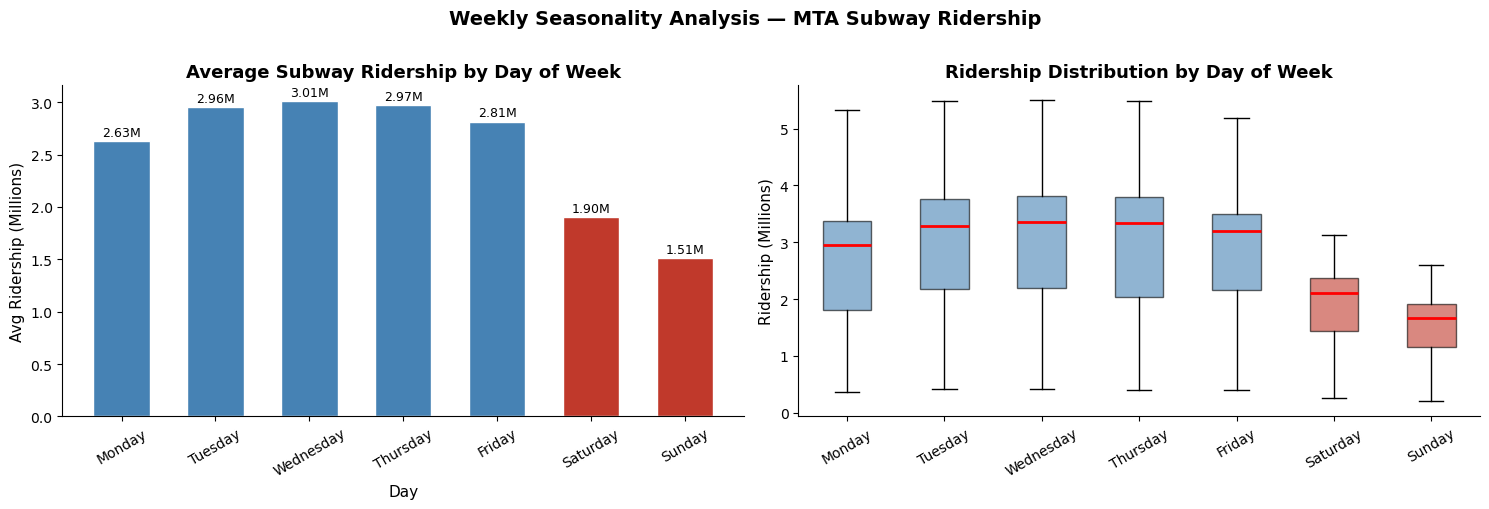

 Saved to Reports


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#bar chart of the day of the week
colors = ['#c0392b' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
bars = axes[0].bar(day_order, avg_by_day/1e6, color=colors, edgecolor='white', width=0.6)
axes[0].set_title("Average Subway Ridership by Day of Week", fontweight='bold')
axes[0].set_ylabel("Avg Ridership (Millions)")
axes[0].set_xlabel("Day")
for bar, val in zip(bars, avg_by_day/1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=9)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

#boxplot by day of week

day_data = [df[df['day_name']==day][TARGET]/1e6 for day in day_order]
bp = axes[1].boxplot(day_data, labels=day_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, day in zip(bp['boxes'], day_order):
    patch.set_facecolor('#c0392b' if day in ['Saturday','Sunday'] else 'steelblue')
    patch.set_alpha(0.6)
axes[1].set_title("Ridership Distribution by Day of Week", fontweight='bold')
axes[1].set_ylabel("Ridership (Millions)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("Weekly Seasonality Analysis — MTA Subway Ridership",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_weekly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to Reports")

In [16]:
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year
df['month_name'] = df['date'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

avg_by_month = df.groupby('month_name')[TARGET].mean().reindex(month_order)

print("AVERAGE RIDERSHIP BY MONTH")

for month, val in avg_by_month.items():
    print(f"  {month:<5}: {val:>12,.0f}")


AVERAGE RIDERSHIP BY MONTH
  Jan  :    2,353,428
  Feb  :    2,512,832
  Mar  :    2,661,711
  Apr  :    2,282,775
  May  :    2,398,359
  Jun  :    2,477,126
  Jul  :    2,353,224
  Aug  :    2,392,631
  Sep  :    2,710,013
  Oct  :    2,865,303
  Nov  :    2,786,123
  Dec  :    2,676,702


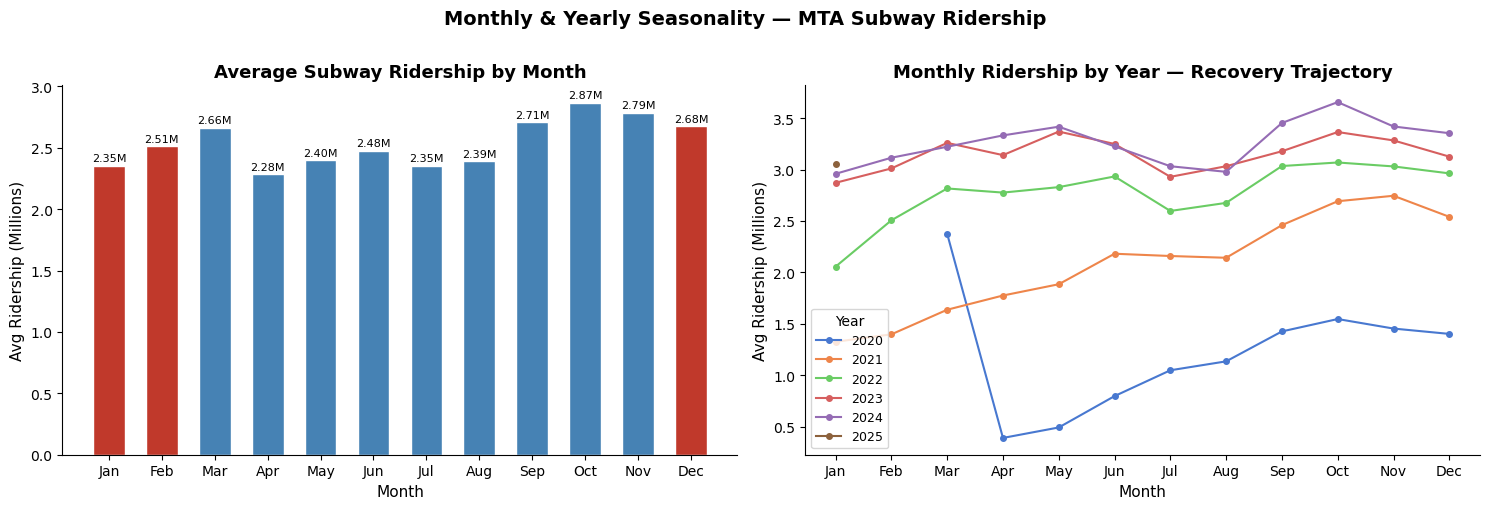

Saved to Reports|


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Average ridership by month bar chart
colors = ['#c0392b' if m in ['Jan','Feb','Dec'] else 'steelblue' for m in month_order]
bars = axes[0].bar(month_order, avg_by_month/1e6, color=colors, edgecolor='white', width=0.6)
axes[0].set_title("Average Subway Ridership by Month", fontweight='bold')
axes[0].set_ylabel("Avg Ridership (Millions)")
axes[0].set_xlabel("Month")
for bar, val in zip(bars, avg_by_month/1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=8)

#Year over year line chart

for year in sorted(df['year'].unique()):
    year_data = df[df['year']==year].groupby('month')[TARGET].mean()
    axes[1].plot(year_data.index, year_data/1e6,
                 marker='o', markersize=4, linewidth=1.5, label=str(year))
axes[1].set_title("Monthly Ridership by Year — Recovery Trajectory", fontweight='bold')
axes[1].set_ylabel("Avg Ridership (Millions)")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_order)
axes[1].legend(title='Year', fontsize=9)\

plt.suptitle("Monthly & Yearly Seasonality — MTA Subway Ridership",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_monthly_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports|")
